Topics covered
- Single neuron, input, weights and bias
- Neruron layer
- Single batch & multiple batches
- Buding dense layer class
- Chaning dense layers
- nnfs dataset 
- broadcasting rules

Course URL https://www.youtube.com/watch?v=SP372QpruDg

#### underlying math
output = X.W + bias per input

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
np.set_printoptions(precision=2)

A neuron is a computing unit it has three parts
- Inputs
- Weights
- Bias
- Output

A single neuron has a single output but it can take multiple inputs. The number of weights and number of inputs are the same. The output of a neuron is sum of products of inputs and correspondign weights. A bias value is added at the end to produce the final output.

In [3]:
inputs = [1   ,   2,    3,  -2]
weights = [0.5, 0.2, -0.1, 0.9]
bias = 2

In [4]:
# 1 * 0.5 + 2 * 0.2 + 3 * -0.1 + -2 * 0.9 + 2
output = sum([x * w for x,w in zip(inputs, weights)]) + bias
print(output)

0.7999999999999998


When there are multiple neurons they are called layer of neurons. Each neuron will have its own weights and biases. Each of the input is processed by all these neurons. Layer of neruons can be represented by an array of array. Biases can be represented by array of biases. Now output contains four values each from each neuron which will be another array.

In [5]:
inputs = [1   ,   2,    3,  -2]
neuron_layer = [
    [0.5, 0.2, -0.1, 0.9], # neuron1
    [0.11, 0.12, -1.1, 1.9], # neuron2
    [1.5, 0.6, -1., 0.01], # neuron3
    [2.5, 1.7, -0.8, 0.2]  # neuron4
]

biases = [2, 3, 4, 6]

In [6]:
outputs = []
for weights, bias in zip(neuron_layer, biases):
    out = sum([x * w for x, w in zip(inputs, weights)]) + bias
    outputs.append(out)

print(outputs)

[0.7999999999999998, -3.75, 3.68, 9.1]


Using numpy and metrics multiplicaiton makes the whole process efficient. In the example we had only one set of inputs, when there are multiple inputs called batches of inputs then using loops and zip commands adds a lot of code. Not just that the code will not be very efficient in terms of computation because metrix and vector multiplications have hardware level optimisations. Therefore in order to take advantage of the underlying hardware we better use the metrix multiplicaiton.

When it comes to multiplying two vectors (a, b, c) dot (p, q, r) = ap + bq + cr we get a scalar value which implice the closeness of these two vectors. Higher the value closer will be those two vectors.  VecA . VecB = A*B*cos(Q)

In [7]:
inputs = [1   ,   2,    3,  -2]
weights = [0.5, 0.2, -0.1, 0.9]
bias = 2
# output = sum([x * w for x,w in zip(inputs, weights)]) + bias
# The above computation can be written as a dot product between inputs and weights
np.dot(inputs, weights) + bias

0.8

In [8]:
inputs = [1   ,   2,    3,  -2] # 1 x 4 metrix
neuron_layer = [
    [0.5, 0.2, -0.1, 0.9], # neuron1
    [0.11, 0.12, -1.1, 1.9], # neuron2
    [1.5, 0.6, -1., 0.01], # neuron3
    [2.5, 1.7, -0.8, 0.2]  # neuron4
]  # 4 x 4 metrix

biases = [2, 3, 4, 6]

# outputs = []
# for weights, bias in zip(neuron_layer, biases):
#     out = sum([x * w for x, w in zip(inputs, weights)]) + bias
#     outputs.append(out)

# Similarly when dealing with a layer of neurons we can multiply the inputs vector with the neruron_layer metrix. 
# But here we need to take transpose of the weight metrics so that input and corresponding weights 
# of each neuron is done correctly

np.dot(inputs, np.array(neuron_layer).T) + biases

array([ 0.8 , -3.75,  3.68,  9.1 ])

#### Dealing with batches of inputs

When there are many inputs they are organised into bathces. So each batch contain inputs which can be represented as a 2D array or a metrix.

In [9]:
batches_of_inputs = [
    [1, 2, 3, -2],
    [-2, 5, -2, 4],
    [-6, 5, 3, 1],
    [7, 9, -4, 9],
    [-2, 6, 1, 5]
]

neuron_layer = [
    [0.5, 0.2, -0.1, 0.9], # neuron1
    [0.11, 0.12, -1.1, 1.9], # neuron2
    [1.5, 0.6, -1., 0.01], # neuron3
    [2.5, 1.7, -0.8, 0.2]  # neuron4
]

bias = [2, 3, 4, 6]

In [10]:
# here we need to multiply each input in the batch with each neuron.
# For each input in each batch there will an output created by each neurons.

In [11]:
np.dot(batches_of_inputs, np.array(neuron_layer).T) + bias

array([[ 0.8 , -3.75,  3.68,  9.1 ],
       [ 5.8 , 13.18,  6.04, 11.9 ],
       [ 0.6 ,  1.54, -4.99, -2.7 ],
       [15.8 , 26.35, 23.99, 43.8 ],
       [ 6.6 , 11.9 ,  3.65, 11.4 ]])

In [12]:
m = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
] # 3 x 3

v = [2, 2, 2] # 1 x 3

In [13]:
np.dot(v, m)

array([24, 30, 36])

The next question to be answered is how to add multiple layers in a neural network. Neural network becomes usable with many layers called hidden layer which comes between input layer and output layers. An interesting observation is that a layer produces number of outputs equal to the number of neurons in the layer. Therefore the next layer should have number of inputs equal to number of outputs of the previous layer.

Here through these many layers we are expressing our problem as a linear combination of many layers

In [76]:
np.random.seed(0)
# lets generate five batches of inputs with 4 input each
input_batches_5x4 = np.random.randint(-10, 10, (5, 4))
# lets create an input layer with 4 inputs and 10 neurons
layer_input_4x10 = np.random.randint(-10, 10, (10, 4))
layer1_bias = np.random.randint(-10, 10, 10)

# lets add a hidden layer with 10 inputs and 5 neurons because previous layer has 10 neurons and
layer_hidden_5x10 = np.random.randint(-10, 10, (5, 10))
layer2_bias = np.random.randint(-10, 10, 5)

# finally lets add an output layer with 5 inputs and 1 neuron which provides our solution.
layer_output_1x5 = np.random.randint(-10, 10, (1, 5))
layer3_bias = np.random.randint(-10, 10)

In [69]:
output1 = np.dot(input_batches_5x4, layer_input_4x10.T) + layer1_bias
output1

array([[ -87,   31, -151,   48,   23, -111,   80,  -66,   -8,  -26],
       [  48,  -79,   40, -117,   16,   82,   46,  105,  -14,   84],
       [ -75, -114,   97,    0,  -34,   44,   28,   -1,   82,   -8],
       [ -16,  -34,  -28, -137,   97,   47,  122,   88,  -16,  122],
       [ -59,  -29,   95,   40,    0,   12,  -20,  -42,   64,  -25]])

In [75]:
output2 = np.dot(output1, layer_hidden_5x10.T) + layer2_bias
output2

array([[ 1397, -1920,  1209,   944,  -943],
       [  390,   235, -1204,  -582,   578],
       [ -397,   379,  1566, -1231,  2856],
       [ 1508, -1288, -1585,  -787,  -525],
       [ -611,   531,  1137, -1192,  1454]])

In [78]:
output3 = np.dot(output2, layer_output_1x5.T) + layer3_bias
output3

array([[-21216],
       [ -8193],
       [  -271],
       [-20050],
       [ 13865]])

In [91]:
network = [(layer_input_4x10, layer1_bias), (layer_hidden_5x10, layer2_bias), (layer_output_1x5, layer3_bias)]

def forward(input_layer):
    output = None
    for i, (layer, bias) in enumerate(network):
        output = np.dot(input_layer, layer.T) + bias
        print("Output for layer =", i+1)
        print(output)
        input_layer = output
    return output

forward(input_batches_5x4);

Output for layer = 1
[[ -87   31 -151   48   23 -111   80  -66   -8  -26]
 [  48  -79   40 -117   16   82   46  105  -14   84]
 [ -75 -114   97    0  -34   44   28   -1   82   -8]
 [ -16  -34  -28 -137   97   47  122   88  -16  122]
 [ -59  -29   95   40    0   12  -20  -42   64  -25]]
Output for layer = 2
[[ 1397 -1920  1209   944  -943]
 [  390   235 -1204  -582   578]
 [ -397   379  1566 -1231  2856]
 [ 1508 -1288 -1585  -787  -525]
 [ -611   531  1137 -1192  1454]]
Output for layer = 3
[[-21216]
 [ -8193]
 [  -271]
 [-20050]
 [ 13865]]


array([[-21216],
       [ -8193],
       [  -271],
       [-20050],
       [ 13865]])

In [93]:
!pip install nnfs


[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [94]:
from nnfs.datasets import spiral_data

In [122]:
# creating a layer class called Denselayer, becuase a class reduces a lot of duplication of code and it makes
# life easier while building a neural network.

class DenseLayer:
    def __init__(self, dim_in, dim_out):
        # here we are creating a transposed metrix to avoid transpose at each evaluation of a layer
        # therfore here columns represent the neurons and rows represent the nth input wights of each
        # neuron
        self.weights = np.random.randn(dim_in, dim_out)
        # using zero as bias for sometime
        self.bias = np.zeros((1, dim_out))
    
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.bias
        return self.output


In [130]:
# network using the dense class
# this time lets use the spiral data from the nnfs datasets, this include a 2D dataset corresponding to a spiral
# here X contains x1, and x2 and Y contains the corrspondign class identifier
X, Y = spiral_data(samples=100, classes=3)

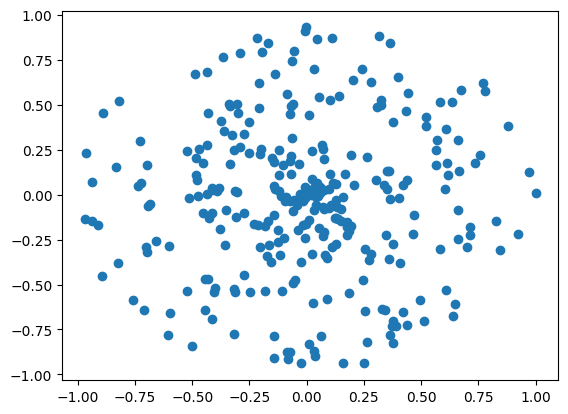

In [117]:
plt.scatter(X[:, 0], X[:, 1])

In [134]:
np.random.seed(0)
dl = DenseLayer(2, 5)
dl.forward(X)

array([[ 0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00],
       [ 6.45e-03,  9.47e-03,  6.25e-03,  1.60e-02,  1.67e-02],
       [ 3.12e-03,  2.05e-02,  8.32e-03,  2.32e-02,  2.77e-02],
       ...,
       [-6.67e-01, -9.09e-01, -6.23e-01, -1.58e+00, -1.64e+00],
       [-1.99e+00,  2.16e-03, -9.51e-01, -2.08e+00, -1.54e+00],
       [-1.83e+00, -3.28e-01, -9.87e-01, -2.24e+00, -1.83e+00]])

In [142]:
# output correspondign to 5th input, each of the 5 neurons (ie dim_out) acts on each of the inputs 
# and produces its result independent of other neurons.
print(X[5])
print(dl.output[5]) 


[0.03 0.04]
[0.02 0.05 0.02 0.07 0.07]


#### Chaining multiple layers

In [168]:
layer1 = DenseLayer(2, 5)
layer2 = DenseLayer(5, 5)
layer3 = DenseLayer(5, 1)

output = layer3.forward(layer2.forward(layer1.forward(X)))
print(output[:5])

[[ 0.  ]
 [-0.03]
 [-0.09]
 [-0.16]
 [-0.17]]


Broadcasting rules
 1. Start from the last diemensions of metrics A & B
 2. Either the dimensions have to be equal or one of them shoudl be 1 or zero
 3. If the rule 2 is satisfied for all the diemensions then the metrices are broadcastable

In [143]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Problem substract max of each rows from the metrics A 

In [148]:
# we can take max in any direction, the last answer is what we actually need becuase we need the max value per row
np.max(A), np.max(A, axis=0), np.max(A, axis=1)

(9, array([7, 8, 9]), array([3, 6, 9]))

In [154]:
A - np.max(A, axis=1)
# array([[-2, -4, -6],
#        [ 1, -1, -3],
#        [ 4,  2,  0]])
# When we substrat the max value from A we get above answer. But this is incorrect
# this happens becaue the of the broadcasting

# shape of A is 3x3 but shape of np.max(A, axis=1) is (0x3)
# as per broadcasting rule the 1st diemension is 0 in np.max(A, axis=1) therefore the dim 0 is replicated along the
# dimension 1 resulting in 
brodcasted_max = np.array([
    [3, 6, 9],
    [3, 6, 9],
    [3, 6, 9]
    ])

A - brodcasted_max
# hence we got the incorrect result.

array([[-2, -4, -6],
       [ 1, -1, -3],
       [ 4,  2,  0]])

In [162]:
# in order to correct this we need to preserve the original number of dimensions as 2 as follows
new_max = np.max(A, axis=1, keepdims=True) # (3, 1)
# now the broadcasting will happen in horizontal diemensions and we get the correct result

A - new_max # we get the expected results here

array([[-2, -1,  0],
       [-2, -1,  0],
       [-2, -1,  0]])